In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../../data")

sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])
print(f"{len(sales)} ngày, từ {sales['Date'].min().date()} đến {sales['Date'].max().date()}")
sales.head()

3833 ngày, từ 2012-07-04 đến 2022-12-31


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 1. Revenue theo ngày + đường trung bình trượt 30 ngày

Cột mờ = doanh thu từng ngày (nhiễu). Đường cam = MA30, lộ sóng mùa vụ.

# EDA khởi động — Revenue & Hiệu ứng Tết

Notebook mẫu cho team. Chạy được ở 2 nơi:
- **VS Code**: mở folder dự án, chọn kernel `.venv` (góc phải trên), Shift+Enter từng cell
- **Google Colab**: upload data lên Drive, sửa `DATA` ở cell dưới thành đường dẫn Drive, thêm cell `!pip install lunardate`


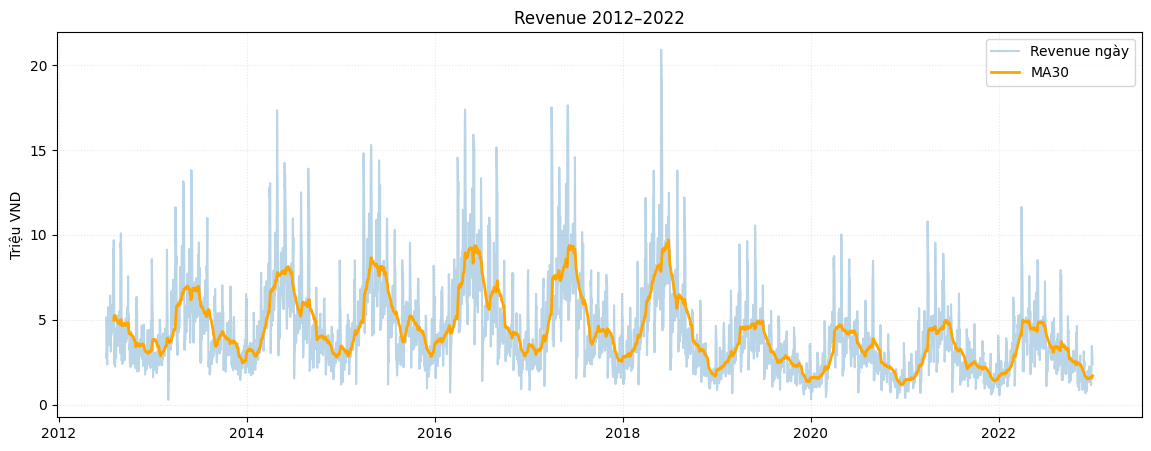

In [2]:
sales["MA30"] = sales["Revenue"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sales["Date"], sales["Revenue"] / 1e6, alpha=0.3, label="Revenue ngày")
ax.plot(sales["Date"], sales["MA30"] / 1e6, color="orange", linewidth=2, label="MA30")
ax.set_ylabel("Triệu VND")
ax.set_title("Revenue 2012–2022")
ax.legend()
ax.grid(alpha=0.3, linestyle=":")
plt.show()

## 2. Doanh thu tháng + margin % — nhìn structural break 2019 và các cú sụt margin

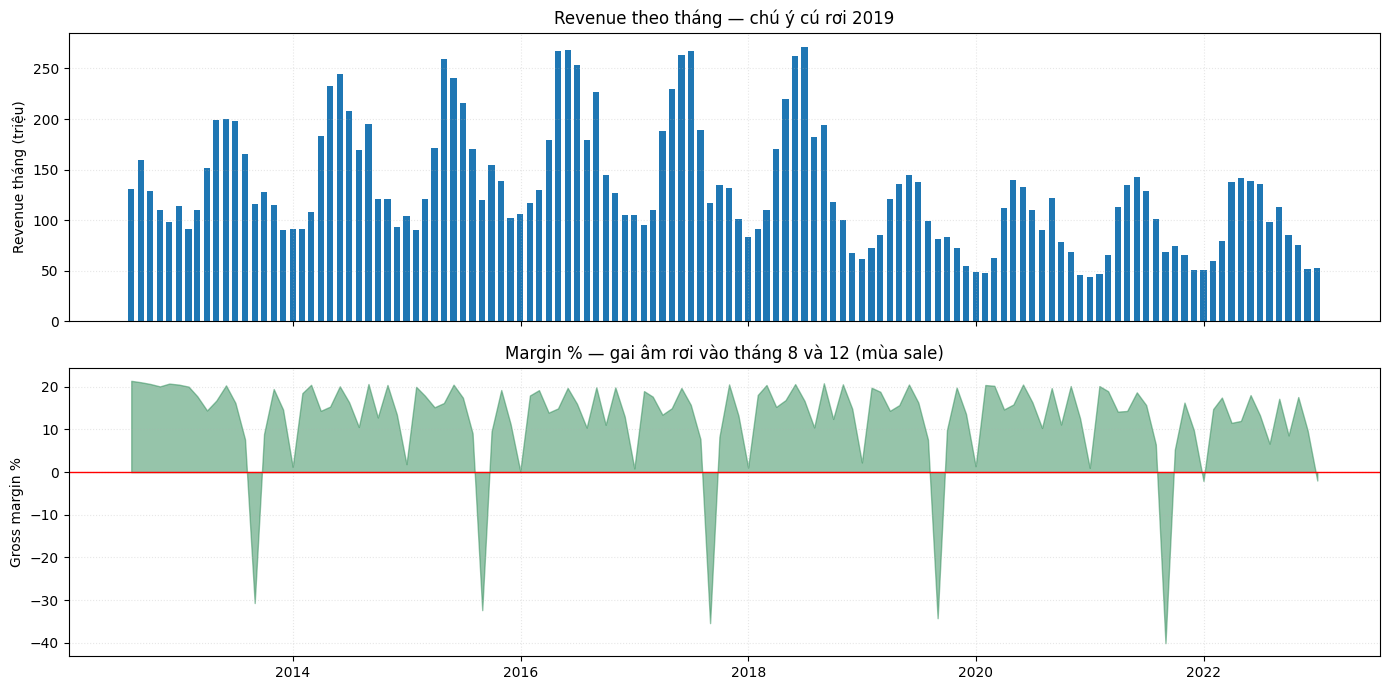

In [10]:
monthly = sales.set_index("Date").resample("ME")[["Revenue", "COGS"]].sum()
monthly["margin_pct"] = (monthly["Revenue"] - monthly["COGS"]) / monthly["Revenue"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.bar(monthly.index, monthly["Revenue"] / 1e6, width=20)
ax1.set_ylabel("Revenue tháng (triệu)")
ax1.set_title("Revenue theo tháng — chú ý cú rơi 2019")
ax2.fill_between(monthly.index, monthly["margin_pct"], color="seagreen", alpha=0.5)
ax2.axhline(0, color="red", linewidth=1)
ax2.set_ylabel("Gross margin %")
ax2.set_title("Margin % — gai âm rơi vào tháng 8 và 12 (mùa sale)")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

## 3. Hiệu ứng Tết — tái tạo chart trong đề bài

Quy mỗi năm về trục "cách mồng 1 bao nhiêu ngày", trung bình 10 cái Tết (2013–2022).

In [13]:
from lunardate import LunarDate

tet_dates = [pd.Timestamp(LunarDate(y, 1, 1).to_solar_date()) for y in range(2013, 2023)]
pd.DataFrame({"nam": range(2013, 2023), "mong_1": [t.date() for t in tet_dates]})

,nam,mong_1
0,2013,2013-02-10
1,2014,2014-01-31
2,2015,2015-02-19
3,2016,2016-02-08
4,2017,2017-01-28
5,2018,2018-02-16
6,2019,2019-02-05
7,2020,2020-01-25
8,2021,2021-02-12
9,2022,2022-02-01


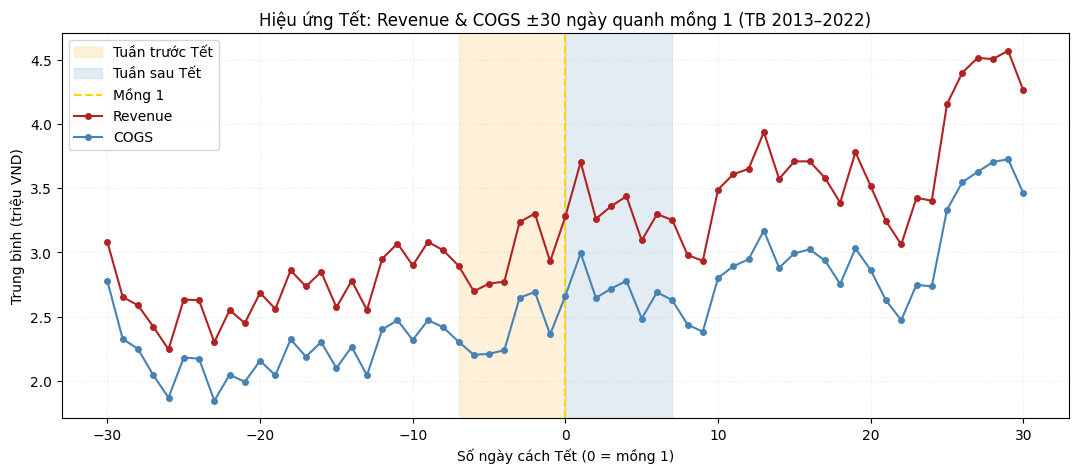

Vùng đáy trước Tết (-30..-15): 2.61 triệu/ngày
Hồi phục sau Tết (+15..+30) : 3.83 triệu/ngày


In [5]:
frames = []
for t in tet_dates:
    w = sales[(sales["Date"] >= t - pd.Timedelta(days=30)) &
              (sales["Date"] <= t + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - t).dt.days
    frames.append(w)
avg = pd.concat(frames).groupby("offset")[["Revenue", "COGS"]].mean() / 1e6

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(-7, 0, color="orange", alpha=0.15, label="Tuần trước Tết")
ax.axvspan(0, 7, color="steelblue", alpha=0.15, label="Tuần sau Tết")
ax.axvline(0, color="gold", linestyle="--", label="Mồng 1")
ax.plot(avg.index, avg["Revenue"], "o-", color="firebrick", ms=4, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color="steelblue", ms=4, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("Trung bình (triệu VND)")
ax.set_title("Hiệu ứng Tết: Revenue & COGS ±30 ngày quanh mồng 1 (TB 2013–2022)")
ax.legend()
ax.grid(alpha=0.3, linestyle=":")
plt.show()

print(f"Vùng đáy trước Tết (-30..-15): {avg.loc[-30:-15, 'Revenue'].mean():.2f} triệu/ngày")
print(f"Hồi phục sau Tết (+15..+30) : {avg.loc[15:30, 'Revenue'].mean():.2f} triệu/ngày")

## Tiếp theo
- Mỗi người copy notebook này làm gốc cho module của mình (D1/D2/D3)
- Số liệu đã chốt ở Phase 0: `Revenue = quantity × unit_price` (mọi đơn, không trừ discount) — xem `phase0_data_check.py`

## 4. CAGR toàn kỳ & theo giai đoạn (gross_revenue, gross_profit)

**CAGR (Compound Annual Growth Rate)** = tốc độ tăng trưởng kép hàng năm nếu giá trị
tăng/giảm đều mỗi năm từ điểm đầu tới điểm cuối. Công thức: `(giá_trị_cuối / giá_trị_đầu) ^ (1/số_năm) - 1`.
Dùng CAGR thay vì % tăng tổng vì nó chuẩn hoá theo số năm — so sánh được giữa các giai đoạn dài ngắn khác nhau.

- `gross_revenue`, `gross_profit = gross_revenue - COGS` tính trực tiếp từ `sales.csv` (đúng định nghĩa
  gross theo Phase 0 QC — khớp order_items 100%, tính cả đơn cancelled, không trừ discount).
- Bỏ năm 2012 khỏi tính CAGR vì chỉ có nửa năm (từ 04/07), gộp vào sẽ làm méo số.


In [ ]:
yearly = (sales[sales["Date"].dt.year.between(2013, 2022)]
          .groupby(sales["Date"].dt.year)[["Revenue", "COGS"]].sum())
yearly["GrossProfit"] = yearly["Revenue"] - yearly["COGS"]
yearly.index.name = "year"

def cagr(v0, v1, n):
    """Compound Annual Growth Rate (%) từ v0 -> v1 qua n năm."""
    return ((v1 / v0) ** (1 / n) - 1) * 100

print("Revenue & GrossProfit theo năm (VND):")
print(yearly.round(0).to_string())

full_rev = cagr(yearly.loc[2013, "Revenue"], yearly.loc[2022, "Revenue"], 9)
full_profit = cagr(yearly.loc[2013, "GrossProfit"], yearly.loc[2022, "GrossProfit"], 9)
print(f"\nCAGR toàn kỳ 2013->2022 (9 năm):")
print(f"  gross_revenue : {full_rev:+.2f}%/năm")
print(f"  gross_profit  : {full_profit:+.2f}%/năm")

print("\nCAGR theo từng giai đoạn 2-3 năm:")
for y0, y1 in [(2013, 2015), (2016, 2018), (2019, 2021)]:
    n = y1 - y0
    rc = cagr(yearly.loc[y0, "Revenue"], yearly.loc[y1, "Revenue"], n)
    pc = cagr(yearly.loc[y0, "GrossProfit"], yearly.loc[y1, "GrossProfit"], n)
    print(f"  {y0}-{y1} (n={n} năm): revenue {rc:+.2f}%/năm | profit {pc:+.2f}%/năm")

yoy_last = cagr(yearly.loc[2021, "Revenue"], yearly.loc[2022, "Revenue"], 1)
print(f"\nYoY riêng 2021->2022 (phục hồi sau đáy): revenue {yoy_last:+.2f}%")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(yearly.index - 0.15, yearly["Revenue"] / 1e9, width=0.3, color="firebrick", label="Revenue")
ax.bar(yearly.index + 0.15, yearly["GrossProfit"] / 1e9, width=0.3, color="seagreen", label="Gross profit")
ax.set_ylabel("Tỷ VND / năm")
ax.set_title("Revenue & Gross profit theo năm — nền cho CAGR toàn kỳ và theo giai đoạn")
ax.legend(frameon=False)
ax.grid(alpha=0.3, linestyle=":")
plt.show()


### Diễn giải nhanh
- CAGR toàn kỳ 11 năm ÂM (~-3.8% revenue, ~-2.7% profit) — KHÔNG có nghĩa công ty tăng trưởng đều đặn
  đi xuống, mà vì có **structural break năm 2019** (đã annotate ở chart mục 1): quy mô doanh thu
  rơi mạnh và không hồi phục về mức 2016-2018.
- Giai đoạn 2013-2015: tăng trưởng dương (+6.8% revenue/năm).
- Giai đoạn 2016-2018: bắt đầu suy giảm (-6.2% revenue/năm).
- Giai đoạn 2019-2021: giảm sâu nhất, đặc biệt profit giảm nhanh hơn revenue (-12.0%/năm) → margin
  bị bào mòn thêm, không chỉ do quy mô nhỏ lại.
- 2022 là năm đầu tiên phục hồi rõ (+12.2% so 2021) — cần theo dõi ở Phase 2 xem đây là bắt đầu
  chu kỳ mới hay chỉ là dao động 1 năm.
